# Hard Requirement

## Map of the Uk

We can now draw a map of the UK that shows the amount of records in the census per region

In [248]:
import geopandas
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import ipywidgets as widgets
from ipywidgets import interact

df = pd.read_csv("../data/publicmicrodatateachingsample.csv")
map = geopandas.read_file("../data/shapeFileData/NUTS1_Jan_2018_UGCB_in_the_UK.shp")

# Rename the region codes to the modern version that the census data uses
map["nuts118cd"] = map["nuts118cd"].map({"UKC": "E12000001", "UKD": "E12000002", "UKE": "E12000003", "UKF": "E12000004", "UKG": "E12000005", "UKH": "E12000006", "UKI": "E12000007", "UKJ": "E12000008", "UKK": "E12000009", "UKL": "W92000004", "UKM": "S99999999" ,"UKN": "N99999999"})
map.rename(columns={"nuts118cd": "region"}, inplace=True)
map

,region,nuts118nm,bng_e,bng_n,long,lat,GlobalID,geometry
0,E12000001,North East (England),417313,600358,-1.728900,55.297031,628608f5-673c-45c8-9082-f57ed9604a20,"MULTIPOLYGON (((397942.931 657535.008, 400000 ..."
1,E12000002,North West (England),350015,506280,-2.772370,54.449451,0413c215-94f7-4f2e-a0fd-37d517177413,"MULTIPOLYGON (((357136.203 587050.898, 356937...."
2,E12000003,Yorkshire and The Humber,446903,448736,-1.287120,53.932640,d608863c-86bd-4877-b3b8-247794a0825a,"POLYGON ((479999.978 517670.16, 481340.496 515..."
3,E12000004,East Midlands (England),477660,322635,-0.849670,52.795719,428c9691-f97b-4fa3-aef8-b3d8c0789cf9,"POLYGON ((516022.702 412210.895, 515854.099 41..."
4,E12000005,West Midlands (England),386294,295477,-2.203580,52.556969,a8a5953c-6a23-4fca-b1c7-96d80a29dd95,"POLYGON ((409402.997 365710.796, 412633.099 36..."
5,E12000006,East of England,571074,263229,0.504146,52.240669,5b0cd82b-5790-499e-92b3-b8f1ab8c601c,"MULTIPOLYGON (((599964.098 346659.983, 608692...."
6,E12000007,London,517516,178392,-0.308640,51.492271,2ae606b7-b7dc-4d57-a422-84064399cbba,"POLYGON ((537543.796 199883.103, 537625.1 1960..."
7,E12000008,South East (England),470062,172924,-0.993110,51.450970,53710b5b-1dfe-4a52-bfb9-a07005f418be,"MULTIPOLYGON (((493941.101 254585.705, 493776...."
8,E12000009,South West (England),285015,102567,-3.633430,50.811192,da810a21-072d-49d1-853e-48b75dd73c53,"MULTIPOLYGON (((416007.596 246053.797, 417496...."
9,W92000004,Wales,263406,242881,-3.994160,52.067410,ec38afc1-b206-49a1-bfaf-48c9836e2d02,"MULTIPOLYGON (((314837.003 381391.297, 315637...."


In [249]:
# Get the counts per region in list format
region_counts = df.groupby("region")["region"].count()
region_counts = region_counts.tolist()

# Scotland and Northern Ireland don't have records so we need to add them manually
region_counts.append(0)
region_counts.append(0)

# Add the counts to the data set
map["pop_counts"] = region_counts
map[["region", "pop_counts"]]

,region,pop_counts
0,E12000001,26767
1,E12000002,75080
2,E12000003,55469
3,E12000004,49440
4,E12000005,60231
5,E12000006,64258
6,E12000007,89489
7,E12000008,94344
8,E12000009,57815
9,W92000004,31458


<Axes: >

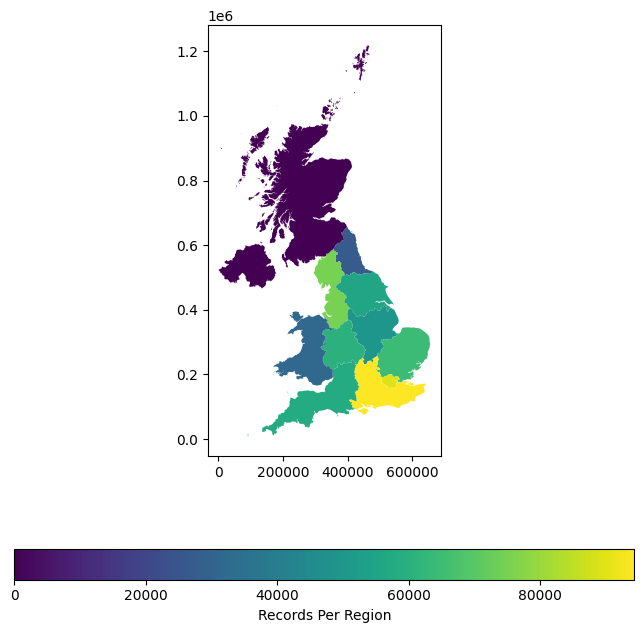

In [250]:
map.plot(
    figsize=(8,8), 
    column="pop_counts", 
    legend=True,
    legend_kwds={"label": "Records Per Region", "orientation": "horizontal"}
    )
